### Round 3 Analysis - HYDROGEL_PACK

In [89]:
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.stats as stats

from pathlib import Path
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import jarque_bera

import prosperity4
from prosperity4.utils.statistics_utils import compute_returns
from prosperity4.utils.dataloader import (
    load_trading_data,
    get_product_data,
    get_day_data,
    get_product_day_data,
    get_price_data,
    get_order_book_data,
    get_volume_data,
    convert_timestamp,
)


plt.style.use("dark_background")
sns.set_palette("pastel")

### Data Loading

In [90]:
REPO_ROOT = Path(prosperity4.__file__).parents[1]
DATA_FOLDER = REPO_ROOT / "prosperity4" / "round3" / "data"
ROUND_NUM = 3
DAYS = [0, 1, 2]

data = load_trading_data(DATA_FOLDER, ROUND_NUM, DAYS)
prices_df = data.get("prices")
trades_df = data.get("trades")

print("Prices Shape :", prices_df.shape if prices_df is not None else None)
print("Trades Shape :", trades_df.shape if trades_df is not None else None)
print("\n--- Prices Head ---")
display(prices_df.head())
print("\n--- Trades Head ---")
display(trades_df.head())

Prices Shape : (360000, 17)
Trades Shape : (4048, 8)

--- Prices Head ---


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,25,NaN,NaN,NaN,NaN,23.0,0.0
1,0,0,VEV_6500,0,16,NaN,NaN,NaN,NaN,1,16,NaN,NaN,NaN,NaN,0.5,0.0
2,0,0,VEV_5500,8,25,NaN,NaN,NaN,NaN,9,25,NaN,NaN,NaN,NaN,8.5,0.0
3,0,0,VEV_5200,100,19,NaN,NaN,NaN,NaN,103,6,104.0,13.0,NaN,NaN,101.5,0.0
4,0,0,VEV_5300,52,6,51.0,19.0,NaN,NaN,54,25,NaN,NaN,NaN,NaN,53.0,0.0



--- Trades Head ---


,timestamp,buyer,seller,symbol,currency,price,quantity,day
0,2500,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5250.0,4,0
1,2900,NaN,NaN,VEV_5400,XIRECS,22.0,3,0
2,2900,NaN,NaN,VEV_5500,XIRECS,8.0,3,0
3,2900,NaN,NaN,VEV_6000,XIRECS,0.0,3,0
4,2900,NaN,NaN,VEV_6500,XIRECS,0.0,3,0


### Splitting the datasets based on the products

In [91]:
products = prices_df["product"].unique()

hydrogel_prices_df = prices_df[prices_df["product"] == "HYDROGEL_PACK"]
hydrogel_trades_df = trades_df[trades_df["symbol"] == "HYDROGEL_PACK"]

In [92]:
"""
Here we are copying the original dataframes, removing the buyer, seller and currency from the trades, summing if there are orders at the
same timestamp and price, then renaming the price and quantity column to market order price and quantity so we know these are bots trades,
then we are merging the 2 datasets so we have all the data on prices and volume, if at that timestamp there's a bot's trade, there's also the 
data for these trades.
At the end we are converting the timestamps so we have timestamp as index
"""

hydrogel_trades = hydrogel_trades_df.copy()

# Grouping and merging the ASH_COATED_OSMIUM so we only have 1 dataset containing both prices and trades, sorted by timestamp
hydrogel_trades = hydrogel_trades.drop(columns = ["buyer", "seller", "currency"])
hydrogel_trades = hydrogel_trades.groupby(["timestamp", "price", "day"], as_index = False).agg({"quantity": "sum"})
hydrogel_trades = hydrogel_trades.rename(columns = { 
                                        "price": "market order price",
                                        "quantity": "market order quantity"})
hydrogel = hydrogel_prices_df.merge(hydrogel_trades[["timestamp", "market order price", "market order quantity", "day"]],
                                on = ["timestamp", "day"],
                                how = "left")

# Convert to continuous timeframe so we don't have 2 separate days
hydrogel = convert_timestamp(hydrogel)

hydrogel.head()

print(hydrogel["mid_price"].mean())


9990.806866666666


# Price and Trades plots

C:\Users\david\AppData\Local\Temp\ipykernel_6344\989015931.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


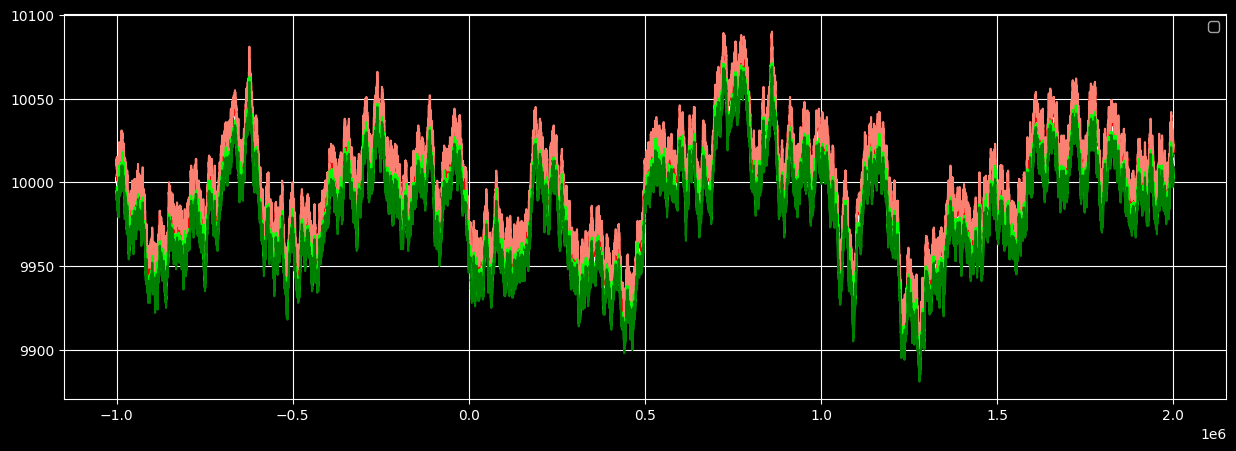

In [93]:
# PLOTS OF PRICES
plt.figure(figsize = (15,5))
plt.plot(hydrogel["t"], hydrogel["mid_price"], color = "white")
plt.plot(hydrogel["t"], hydrogel["ask_price_1"], color = "red")
plt.plot(hydrogel["t"], hydrogel["ask_price_2"], color = "salmon")
plt.plot(hydrogel["t"], hydrogel["bid_price_1"], color = "lime")
plt.plot(hydrogel["t"], hydrogel["bid_price_2"], color = "green")
plt.grid(True)
plt.legend()
plt.show()

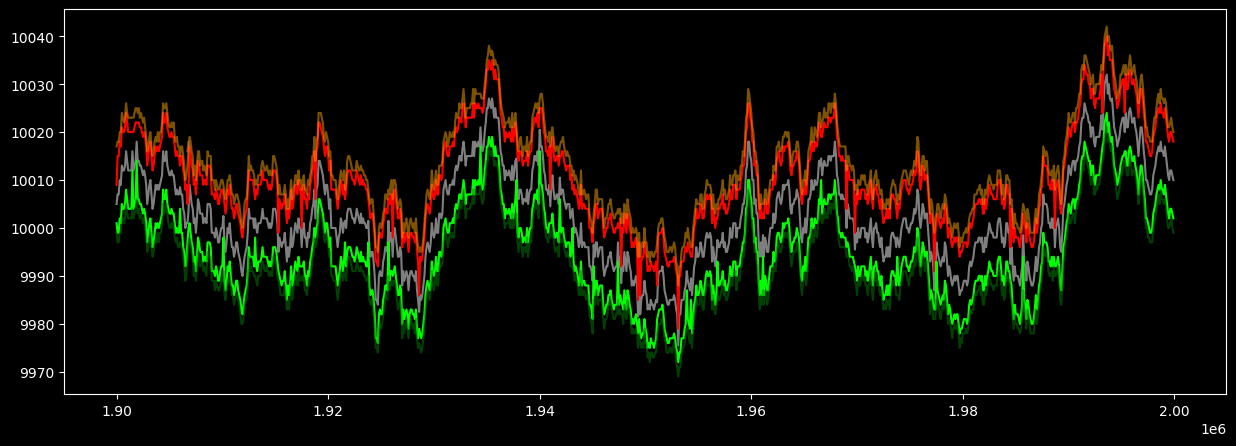

In [94]:
plt.figure(figsize=(15,5))
plt.plot(hydrogel["t"][-1000:], hydrogel["mid_price"][-1000:], color = "white", alpha = 0.5)
plt.plot(hydrogel["t"][-1000:], hydrogel["ask_price_1"][-1000:], color = "red", alpha = 1)
plt.plot(hydrogel["t"][-1000:], hydrogel["ask_price_2"][-1000:], color = "orange", alpha = 0.5)
plt.plot(hydrogel["t"][-1000:], hydrogel["ask_price_3"][-1000:], color = "salmon", alpha = 0.5)
plt.plot(hydrogel["t"][-1000:], hydrogel["bid_price_1"][-1000:], color = "lime", alpha = 1)
plt.plot(hydrogel["t"][-1000:], hydrogel["bid_price_2"][-1000:], color = "green", alpha = 0.5)
plt.plot(hydrogel["t"][-1000:], hydrogel["bid_price_3"][-1000:], color = "darkgreen", alpha = 0.5)
plt.show()

### KALMAN FILTER FV AND Z SCORE

In [95]:
def compute_max_vol_fv(df: pd.DataFrame, fast_window: int = 10) -> pd.DataFrame:
    df = df.copy()

    bid_prices  = df[["bid_price_1",  "bid_price_2",  "bid_price_3"]].values
    bid_volumes = df[["bid_volume_1", "bid_volume_2", "bid_volume_3"]].values
    ask_prices  = df[["ask_price_1",  "ask_price_2",  "ask_price_3"]].values
    ask_volumes = df[["ask_volume_1", "ask_volume_2", "ask_volume_3"]].values

    n = len(df)

    bid_all_nan = np.all(np.isnan(bid_volumes), axis=1)
    ask_all_nan = np.all(np.isnan(ask_volumes), axis=1)

    bid_argmax = np.where(bid_all_nan, 0, np.nanargmax(np.where(np.isnan(bid_volumes), -np.inf, bid_volumes), axis=1))
    ask_argmax = np.where(ask_all_nan, 0, np.nanargmax(np.where(np.isnan(ask_volumes), -np.inf, ask_volumes), axis=1))

    max_vol_bid = bid_prices[np.arange(n), bid_argmax]
    max_vol_ask = ask_prices[np.arange(n), ask_argmax]

    max_vol_bid = np.where(bid_all_nan, np.nan, max_vol_bid)
    max_vol_ask = np.where(ask_all_nan, np.nan, max_vol_ask)

    df["max_vol_bid"] = max_vol_bid
    df["max_vol_ask"] = max_vol_ask

    # Raw FV: midpoint; fall back to whichever side is present
    both_present = ~np.isnan(max_vol_bid) & ~np.isnan(max_vol_ask)
    only_bid     = ~np.isnan(max_vol_bid) &  np.isnan(max_vol_ask)
    only_ask     =  np.isnan(max_vol_bid) & ~np.isnan(max_vol_ask)

    raw_fv = np.where(both_present, (max_vol_bid + max_vol_ask) / 2,
             np.where(only_bid,     max_vol_bid,
             np.where(only_ask,     max_vol_ask, np.nan)))

    # Forward-fill the NaN (both absent) rows with the last valid value
    raw_fv_series = pd.Series(raw_fv).ffill()
    df["fv"] = raw_fv_series.values


    return df

hydrogel = compute_max_vol_fv(hydrogel, fast_window=10)
hydrogel[["max_vol_bid", "max_vol_ask", "fv"]].head(10)

,max_vol_bid,max_vol_ask,fv
0,9990.0,10010.0,10000.0
1,9990.0,10011.0,10000.5
2,9992.0,10013.0,10002.5
3,9992.0,10013.0,10002.5
4,9993.0,10014.0,10003.5
5,9989.0,10010.0,9999.5
6,9991.0,10012.0,10001.5
7,9993.0,10014.0,10003.5
8,9993.0,10014.0,10003.5
9,9994.0,10015.0,10004.5


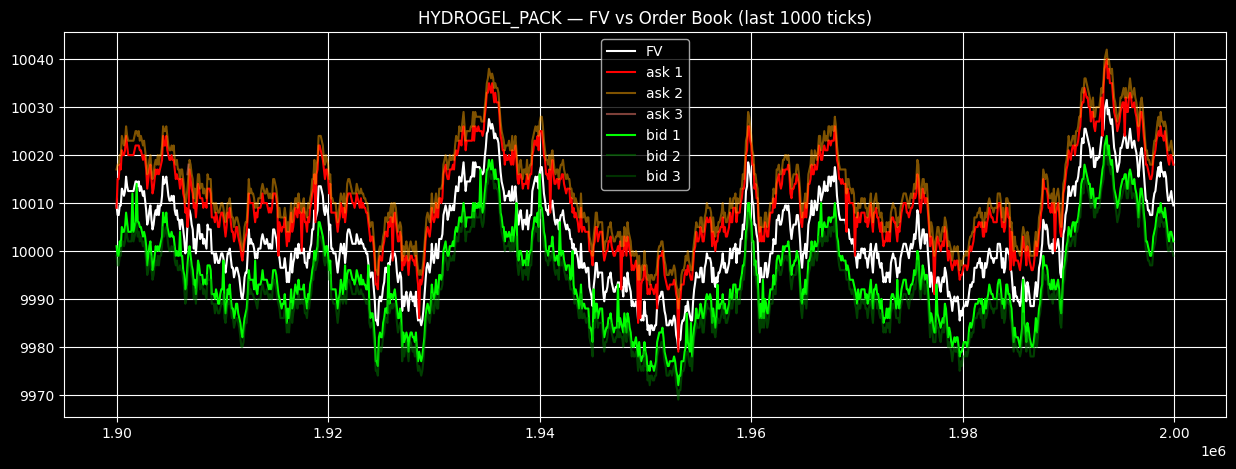

In [96]:
plt.figure(figsize=(15, 5))
plt.plot(hydrogel["t"][-1000:], hydrogel["fv"][-1000:],    color="white",  linewidth=1.5, label="FV")
plt.plot(hydrogel["t"][-1000:], hydrogel["ask_price_1"][-1000:], color="red",       alpha=1,   label="ask 1")
plt.plot(hydrogel["t"][-1000:], hydrogel["ask_price_2"][-1000:], color="orange",    alpha=0.5, label="ask 2")
plt.plot(hydrogel["t"][-1000:], hydrogel["ask_price_3"][-1000:], color="salmon",    alpha=0.5, label="ask 3")
plt.plot(hydrogel["t"][-1000:], hydrogel["bid_price_1"][-1000:], color="lime",      alpha=1,   label="bid 1")
plt.plot(hydrogel["t"][-1000:], hydrogel["bid_price_2"][-1000:], color="green",     alpha=0.5, label="bid 2")
plt.plot(hydrogel["t"][-1000:], hydrogel["bid_price_3"][-1000:], color="darkgreen", alpha=0.5, label="bid 3")
plt.legend()
plt.grid(True)
plt.title("HYDROGEL_PACK — FV vs Order Book (last 1000 ticks)")
plt.show()

In [97]:
# Z-Score of SMA-10 FV vs its 500-tick rolling SMA
WINDOW = 100
rolling_mean = hydrogel["fv"].rolling(window = WINDOW).mean()

hydrogel["distance"] = hydrogel["fv"] - rolling_mean 
hydrogel.head(5)

,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,...,ask_volume_3,mid_price,profit_and_loss,market order price,market order quantity,t,max_vol_bid,max_vol_ask,fv,distance
0,HYDROGEL_PACK,9992,15,9990.0,30.0,NaN,NaN,10008,15,10010.0,...,NaN,10000.0,0.0,NaN,NaN,-1000000,9990.0,10010.0,10000.0,NaN
1,HYDROGEL_PACK,9992,13,9990.0,30.0,NaN,NaN,10008,13,10011.0,...,NaN,10000.0,0.0,NaN,NaN,-999900,9990.0,10011.0,10000.5,NaN
2,HYDROGEL_PACK,9995,13,9992.0,21.0,NaN,NaN,10011,13,10013.0,...,NaN,10003.0,0.0,NaN,NaN,-999800,9992.0,10013.0,10002.5,NaN
3,HYDROGEL_PACK,9994,11,9992.0,23.0,NaN,NaN,10010,11,10013.0,...,NaN,10002.0,0.0,NaN,NaN,-999700,9992.0,10013.0,10002.5,NaN
4,HYDROGEL_PACK,9995,13,9993.0,23.0,NaN,NaN,10011,13,10014.0,...,NaN,10003.0,0.0,NaN,NaN,-999600,9993.0,10014.0,10003.5,NaN


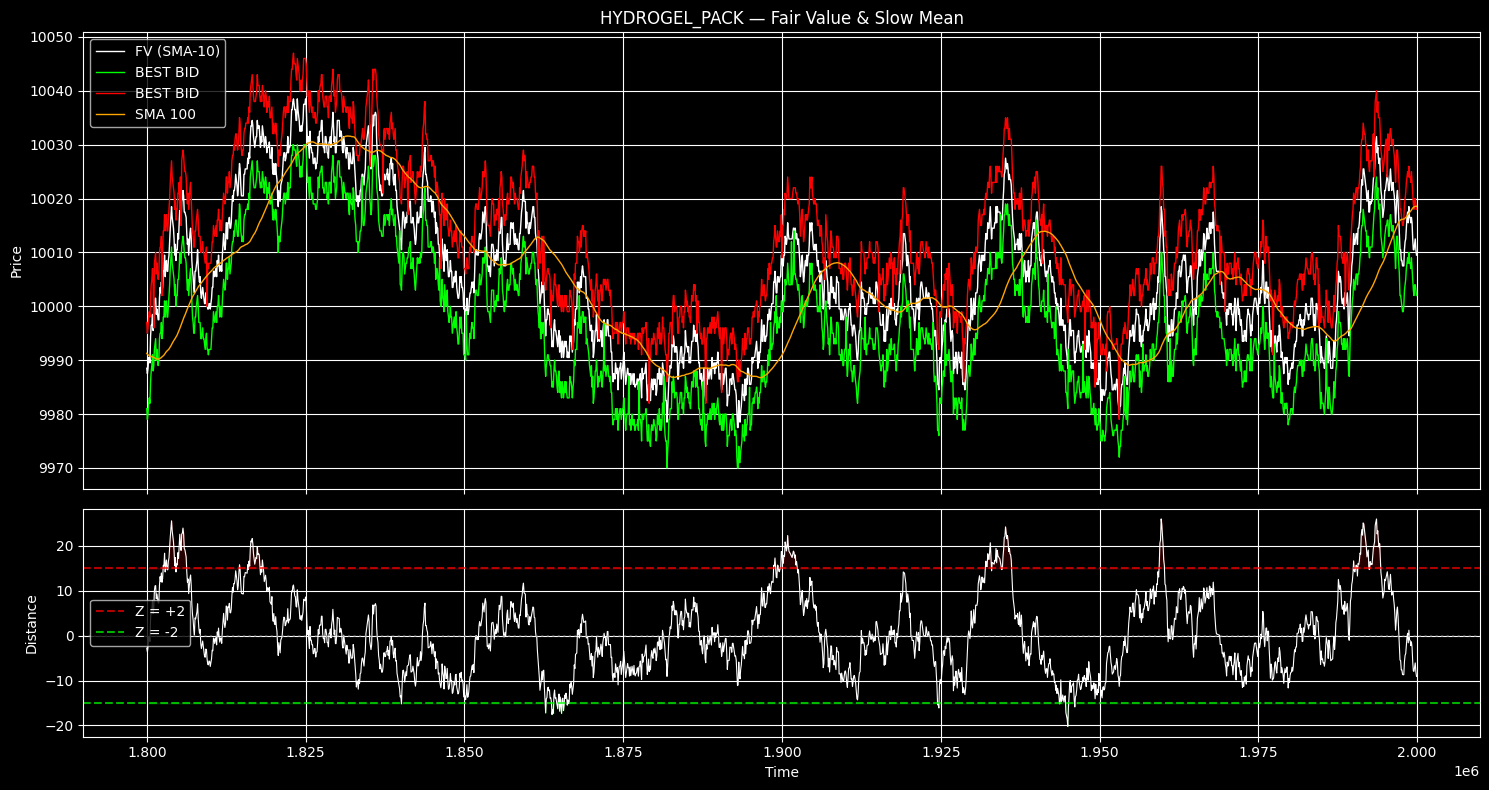

In [98]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(hydrogel["t"][-2000:], hydrogel["fv"][-2000:],   color="white",  linewidth=1,   label="FV (SMA-10)")
ax1.plot(hydrogel["t"][-2000:], hydrogel["bid_price_1"][-2000:], color="lime", linewidth = 1, label = "BEST BID")
ax1.plot(hydrogel["t"][-2000:], hydrogel["ask_price_1"][-2000:], color="red", linewidth = 1, label = "BEST BID")
ax1.plot(hydrogel["t"][-2000:], rolling_mean[-2000:],     color="orange", linewidth=1,   label=f"SMA {WINDOW}")
ax1.legend()
ax1.grid(True)
ax1.set_ylabel("Price")
ax1.set_title("HYDROGEL_PACK — Fair Value & Slow Mean")

ax2.plot(hydrogel["t"][-2000:], hydrogel["distance"][-2000:], color="white", linewidth=0.8)
ax2.axhline( 15, color="red",  linestyle="--", alpha=0.7, label="Z = +2")
ax2.axhline(-15, color="lime", linestyle="--", alpha=0.7, label="Z = -2")
ax2.axhline( 0, color="gray", linestyle=":",  alpha=0.5)
ax2.fill_between(hydrogel["t"][-2000:],  15, hydrogel["distance"][-2000:].clip(lower=15),  color="red",  alpha=0.15)
ax2.fill_between(hydrogel["t"][-2000:], -15, hydrogel["distance"][-2000:].clip(upper=-15), color="lime", alpha=0.15)
ax2.set_ylabel("Distance")
ax2.set_xlabel("Time")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

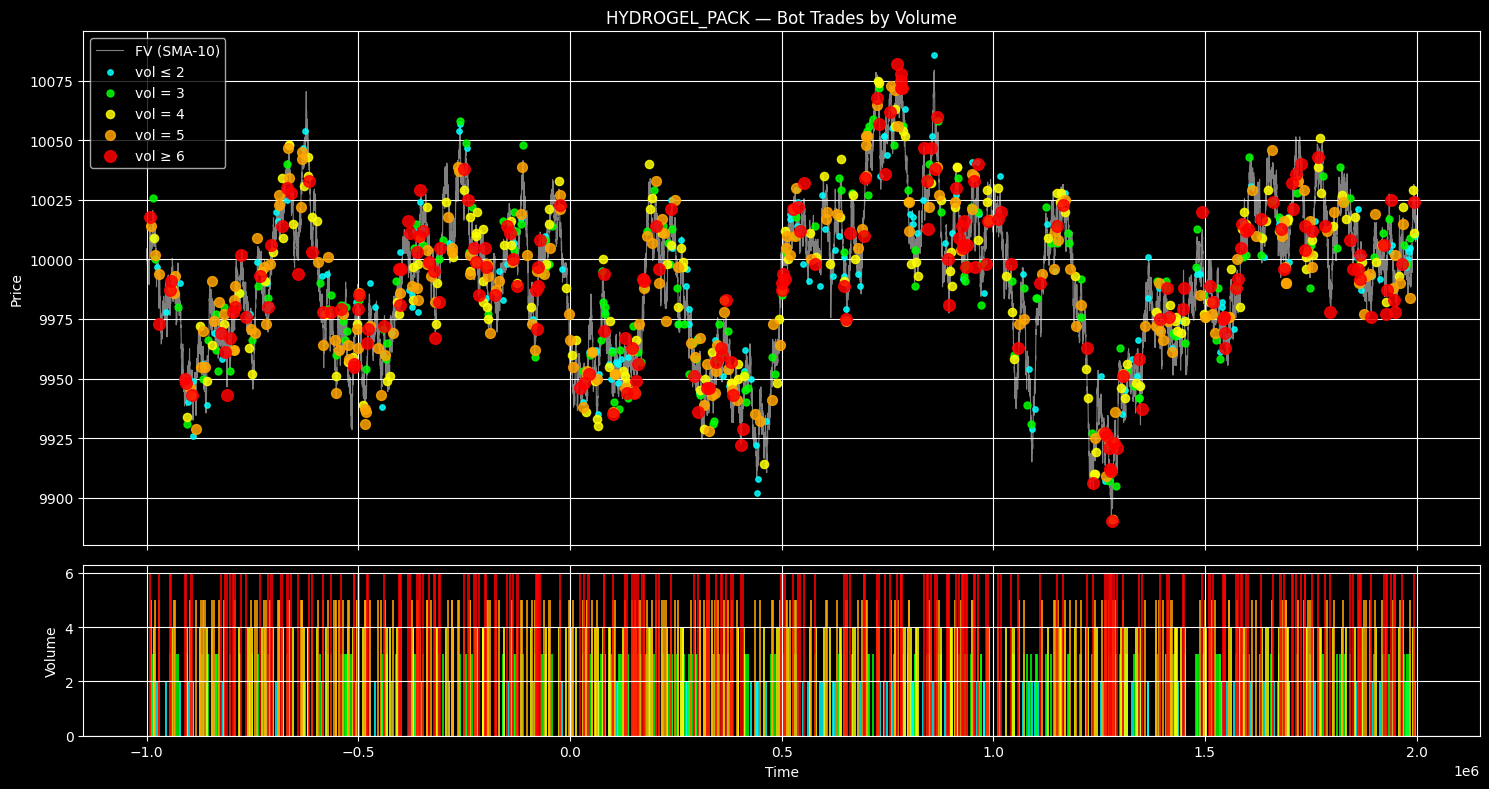

Total trades: 1010
  vol ≤ 2     :  193  (19.1%)
  vol = 3     :  198  (19.6%)
  vol = 4     :  202  (20.0%)
  vol = 5     :  212  (21.0%)
  vol ≥ 6     :  205  (20.3%)


In [99]:
BINS   = [2, 3, 4, 5, 6]           # upper edge of each bucket (last = "≥ 6")
COLORS = ["cyan", "lime", "yellow", "orange", "red"]
SIZES  = [15, 25, 35, 50, 70]

trades_mask = hydrogel["market order price"].notna()
trades      = hydrogel[trades_mask].copy()

def bucket(qty):
    for i, threshold in enumerate(BINS):
        if qty <= threshold:
            return i
    return len(BINS) - 1

trades["bucket"] = trades["market order quantity"].apply(bucket)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

ax1.plot(hydrogel["t"], hydrogel["fv"], color="white", linewidth=0.8, alpha=0.5, label="FV (SMA-10)")

labels = [f"vol ≤ {BINS[0]}"] + [f"vol = {BINS[i]}" for i in range(1, len(BINS) - 1)] + [f"vol ≥ {BINS[-1]}"]

for i, (color, size, label) in enumerate(zip(COLORS, SIZES, labels)):
    g = trades[trades["bucket"] == i]
    ax1.scatter(g["t"], g["market order price"], c=color, s=size, alpha=0.85, zorder=3 + i, label=label)

ax1.set_ylabel("Price")
ax1.set_title("HYDROGEL_PACK — Bot Trades by Volume")
ax1.legend()
ax1.grid(True)

for i, color in enumerate(COLORS):
    g = trades[trades["bucket"] == i]
    ax2.bar(g["t"], g["market order quantity"], width=5000, color=color, alpha=0.8)

ax2.set_ylabel("Volume")
ax2.set_xlabel("Time")
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Total trades: {len(trades)}")
for i, label in enumerate(labels):
    g = trades[trades["bucket"] == i]
    print(f"  {label:12s}: {len(g):4d}  ({100*len(g)/len(trades):.1f}%)")

In [100]:
mean_mid = hydrogel["mid_price"].mean()
print(f"Mean mid price: {mean_mid:.4f}")

Mean mid price: 9990.8069


---
## Returns Analysis

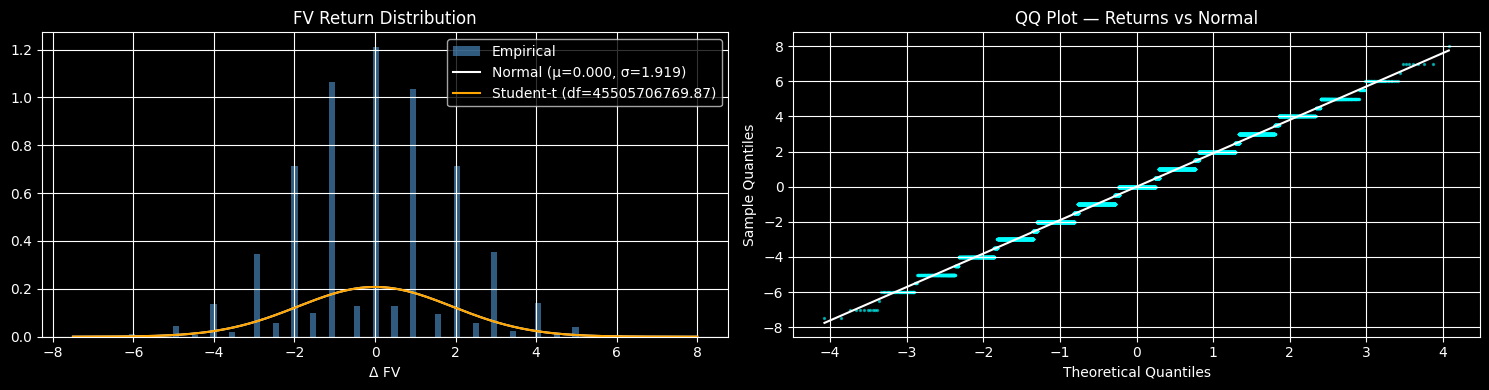

Mean   : 0.0003
Std    : 1.9191
Skew   : 0.0006
Kurt   : -0.0034  (excess)

Jarque-Bera stat : 0.02  p-value : 0.9912
→ Returns are normally distributed at 5% level


In [75]:
# Tick-by-tick price changes on the fair value
hydrogel["fv_return"] = hydrogel["fv"].diff()
returns = hydrogel["fv_return"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Histogram with fitted normal and t-distribution
ax = axes[0]
ax.hist(returns, bins=100, density=True, color="steelblue", alpha=0.7, label="Empirical")

x = np.linspace(returns.min(), returns.max(), 500)

mu, sigma = stats.norm.fit(returns)
ax.plot(x, stats.norm.pdf(x, mu, sigma), color="white", linewidth=1.5, label=f"Normal (μ={mu:.3f}, σ={sigma:.3f})")

df_t, loc_t, scale_t = stats.t.fit(returns)
ax.plot(x, stats.t.pdf(x, df_t, loc_t, scale_t), color="orange", linewidth=1.5, label=f"Student-t (df={df_t:.2f})")

ax.set_title("FV Return Distribution")
ax.set_xlabel("Δ FV")
ax.legend()
ax.grid(True)

# QQ plot vs normal
ax = axes[1]
(osm, osr), (slope, intercept, _) = stats.probplot(returns, dist="norm")
ax.scatter(osm, osr, s=2, color="cyan", alpha=0.5)
ax.plot(osm, slope * np.array(osm) + intercept, color="white", linewidth=1.5)
ax.set_title("QQ Plot — Returns vs Normal")
ax.set_xlabel("Theoretical Quantiles")
ax.set_ylabel("Sample Quantiles")
ax.grid(True)

plt.tight_layout()
plt.show()

print(f"Mean   : {returns.mean():.4f}")
print(f"Std    : {returns.std():.4f}")
print(f"Skew   : {returns.skew():.4f}")
print(f"Kurt   : {returns.kurtosis():.4f}  (excess)")

jb_stat, jb_p, skew_jb, kurt_jb = jarque_bera(returns)
print(f"\nJarque-Bera stat : {jb_stat:.2f}  p-value : {jb_p:.4f}")
print("→ Returns are " + ("NOT " if jb_p < 0.05 else "") + "normally distributed at 5% level")

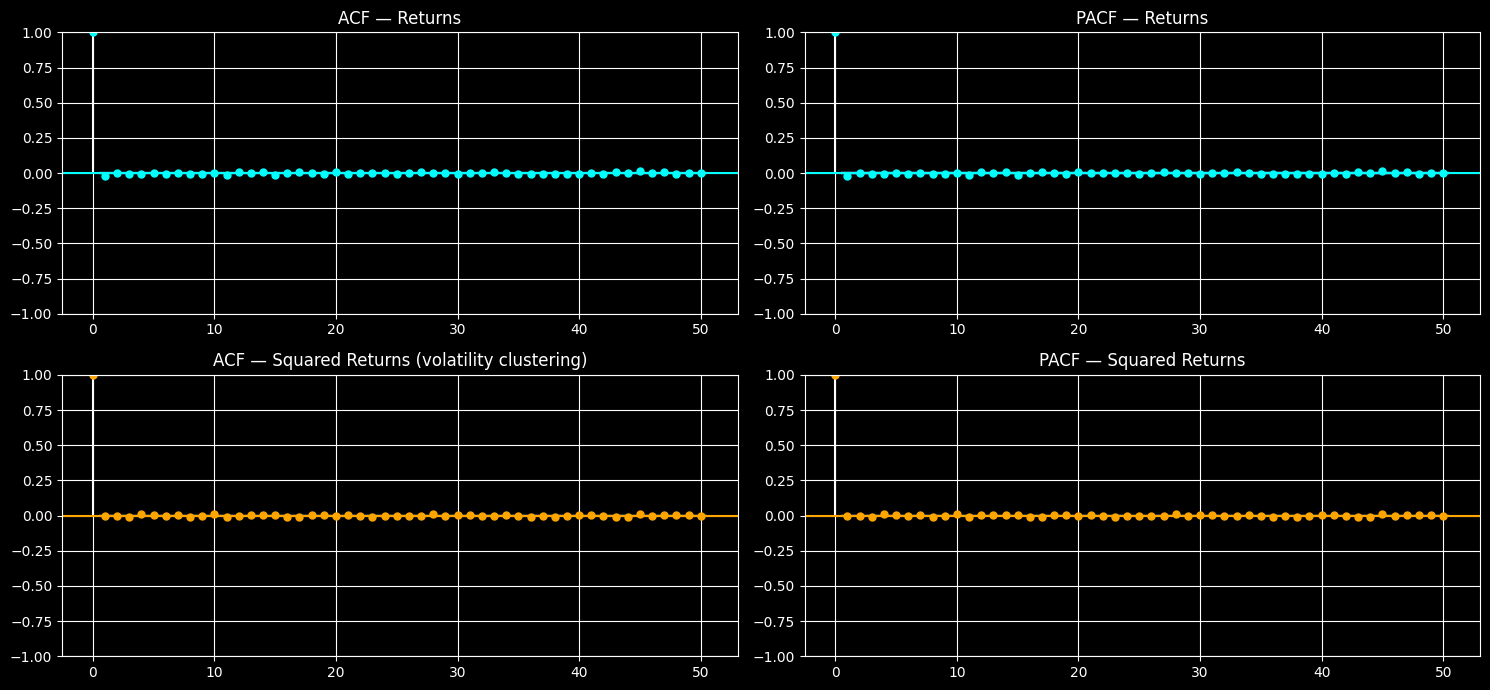

In [76]:
# ACF / PACF of returns and squared returns (volatility clustering check)
fig, axes = plt.subplots(2, 2, figsize=(15, 7))

plot_acf (returns,           ax=axes[0, 0], lags=50, color="cyan",   title="ACF — Returns")
plot_pacf(returns,           ax=axes[0, 1], lags=50, color="cyan",   title="PACF — Returns", method="ywm")
plot_acf (returns ** 2,      ax=axes[1, 0], lags=50, color="orange", title="ACF — Squared Returns (volatility clustering)")
plot_pacf(returns ** 2,      ax=axes[1, 1], lags=50, color="orange", title="PACF — Squared Returns", method="ywm")

for ax in axes.flat:
    ax.grid(True)

plt.tight_layout()
plt.show()

In [77]:
# ADF stationarity tests
for series_name, series in [("FV (mid)", hydrogel["fv"]), ("FV Returns", returns)]:
    result = adfuller(series.dropna())
    print(f"--- {series_name} ---")
    print(f"  ADF stat : {result[0]:.4f}")
    print(f"  p-value  : {result[1]:.4f}")
    print(f"  {'Stationary ✓' if result[1] < 0.05 else 'Non-stationary ✗'} at 5% level\n")

--- FV (mid) ---
  ADF stat : -5.1033
  p-value  : 0.0000
  Stationary ✓ at 5% level

--- FV Returns ---
  ADF stat : -176.3419
  p-value  : 0.0000
  Stationary ✓ at 5% level



---
## Correlation with VELVETFRUIT_EXTRACT

Merged rows: 30000


,t,fv,hyd_mid,vfe_mid
0,-1000000,10000.0,10000.0,5250.0
1,-999900,10000.5,10000.0,5250.5
2,-999800,10002.5,10003.0,5250.5
3,-999700,10002.5,10002.0,5250.5
4,-999600,10003.5,10003.0,5250.5


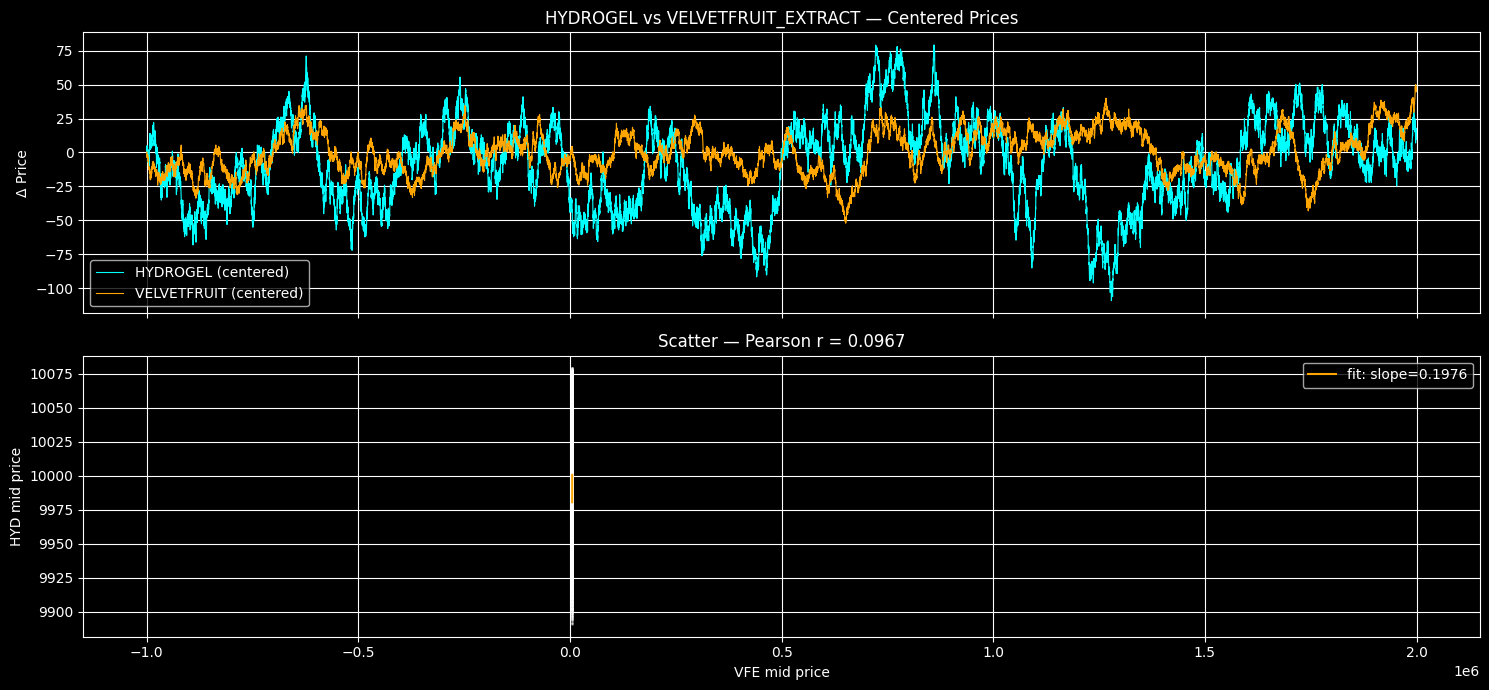

In [78]:
# Load and prepare VELVETFRUIT_EXTRACT
vfe_df = prices_df[prices_df["product"] == "VELVETFRUIT_EXTRACT"].copy()
vfe_df = convert_timestamp(vfe_df)
vfe_df = vfe_df[["t", "mid_price"]].rename(columns={"mid_price": "vfe_mid"})

# Merge on continuous timestamp
merged = hydrogel[["t", "fv", "mid_price"]].rename(columns={"mid_price": "hyd_mid"}).merge(
    vfe_df, on="t", how="inner"
).dropna()

print(f"Merged rows: {len(merged)}")
display(merged.head())

# Normalize both to start at 0 for visual comparison
merged["hyd_norm"] = merged["hyd_mid"] - merged["hyd_mid"].iloc[0]
merged["vfe_norm"] = merged["vfe_mid"] - merged["vfe_mid"].iloc[0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

ax1.plot(merged["t"], merged["hyd_norm"], color="cyan",   linewidth=0.8, label="HYDROGEL (centered)")
ax1.plot(merged["t"], merged["vfe_norm"], color="orange", linewidth=0.8, label="VELVETFRUIT (centered)")
ax1.set_ylabel("Δ Price")
ax1.set_title("HYDROGEL vs VELVETFRUIT_EXTRACT — Centered Prices")
ax1.legend()
ax1.grid(True)

corr = merged["hyd_mid"].corr(merged["vfe_mid"])
ax2.scatter(merged["vfe_mid"], merged["hyd_mid"], s=1, alpha=0.3, color="white")
m, b = np.polyfit(merged["vfe_mid"], merged["hyd_mid"], 1)
xline = np.linspace(merged["vfe_mid"].min(), merged["vfe_mid"].max(), 200)
ax2.plot(xline, m * xline + b, color="orange", linewidth=1.5, label=f"fit: slope={m:.4f}")
ax2.set_xlabel("VFE mid price")
ax2.set_ylabel("HYD mid price")
ax2.set_title(f"Scatter — Pearson r = {corr:.4f}")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

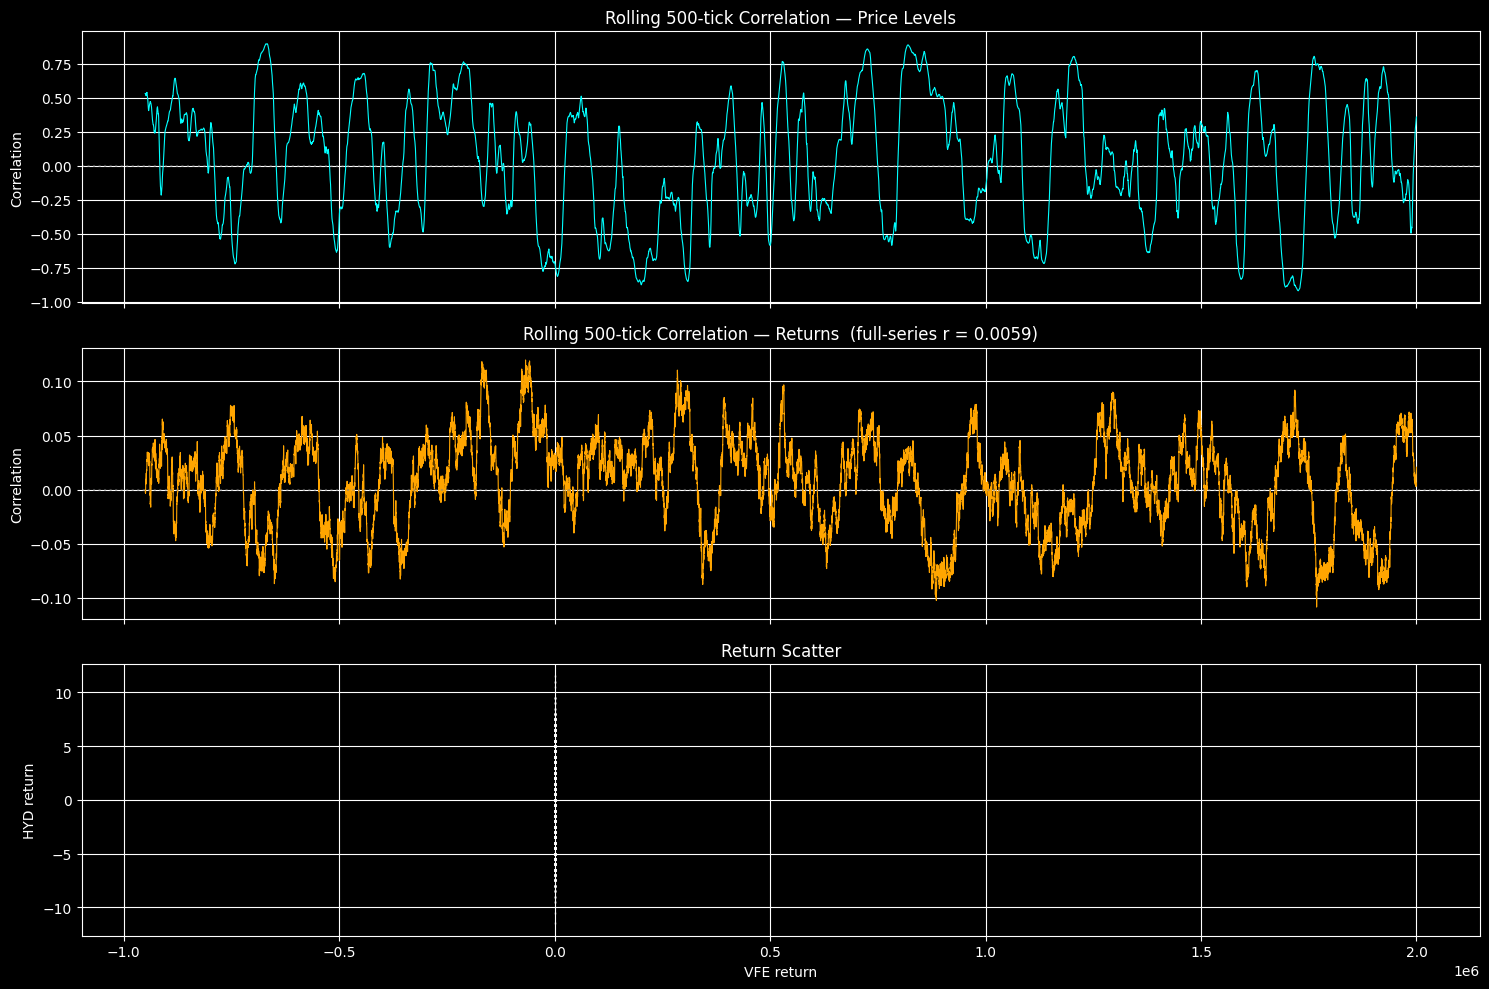

In [79]:
# Rolling correlation + return correlation
ROLL_WIN = 500

merged["hyd_ret"] = merged["hyd_mid"].diff()
merged["vfe_ret"] = merged["vfe_mid"].diff()
merged["rolling_corr_price"]  = merged["hyd_mid"].rolling(ROLL_WIN).corr(merged["vfe_mid"])
merged["rolling_corr_return"] = merged["hyd_ret"].rolling(ROLL_WIN).corr(merged["vfe_ret"])

ret_corr = merged["hyd_ret"].corr(merged["vfe_ret"])

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

axes[0].plot(merged["t"], merged["rolling_corr_price"], color="cyan", linewidth=0.8)
axes[0].axhline(0, color="gray", linestyle=":", alpha=0.5)
axes[0].set_ylabel("Correlation")
axes[0].set_title(f"Rolling {ROLL_WIN}-tick Correlation — Price Levels")
axes[0].grid(True)

axes[1].plot(merged["t"], merged["rolling_corr_return"], color="orange", linewidth=0.8)
axes[1].axhline(0, color="gray", linestyle=":", alpha=0.5)
axes[1].set_ylabel("Correlation")
axes[1].set_title(f"Rolling {ROLL_WIN}-tick Correlation — Returns  (full-series r = {ret_corr:.4f})")
axes[1].grid(True)

axes[2].scatter(merged["vfe_ret"], merged["hyd_ret"], s=1, alpha=0.2, color="white")
axes[2].set_xlabel("VFE return")
axes[2].set_ylabel("HYD return")
axes[2].set_title("Return Scatter")
axes[2].grid(True)

plt.tight_layout()
plt.show()

---
## Distance Strategy Backtest

In [80]:
BT_SMA_WINDOW  = 100
BT_THRESHOLD   = 15

bt = hydrogel[["t", "fv"]].copy().dropna().reset_index(drop=True)
bt["sma"]      = bt["fv"].rolling(BT_SMA_WINDOW, min_periods=1).mean()
bt["distance"] = bt["fv"] - bt["sma"]

# State machine: enter short on dist > threshold, exit when dist < 0; opposite for long
pos, positions = 0, []
for d in bt["distance"]:
    if d > BT_THRESHOLD:
        pos = -1
    elif d < -BT_THRESHOLD:
        pos = 1
    elif d < 0 and pos == -1:
        pos = 0
    elif d > 0 and pos == 1:
        pos = 0
    positions.append(pos)

bt["position"]     = positions
bt["fv_chg"]       = bt["fv"].diff()
bt["strat_pnl"]    = bt["position"].shift(1) * bt["fv_chg"]
bt["cum_pnl"]      = bt["strat_pnl"].cumsum()
bt["bh_pnl"]       = bt["fv_chg"].cumsum()   # buy-and-hold baseline

total_pnl   = bt["cum_pnl"].iloc[-1]
n_trades    = (bt["position"].diff().abs() > 0).sum()
sharpe_raw  = bt["strat_pnl"].mean() / bt["strat_pnl"].std() * np.sqrt(len(bt))

print(f"Total PnL   : {total_pnl:.2f}")
print(f"Num signals : {n_trades}")
print(f"Sharpe (raw): {sharpe_raw:.3f}")
print(f"Time in mkt : {100*(bt['position'] != 0).mean():.1f}%")

Total PnL   : 328.50
Num signals : 364
Sharpe (raw): 1.545
Time in mkt : 41.1%


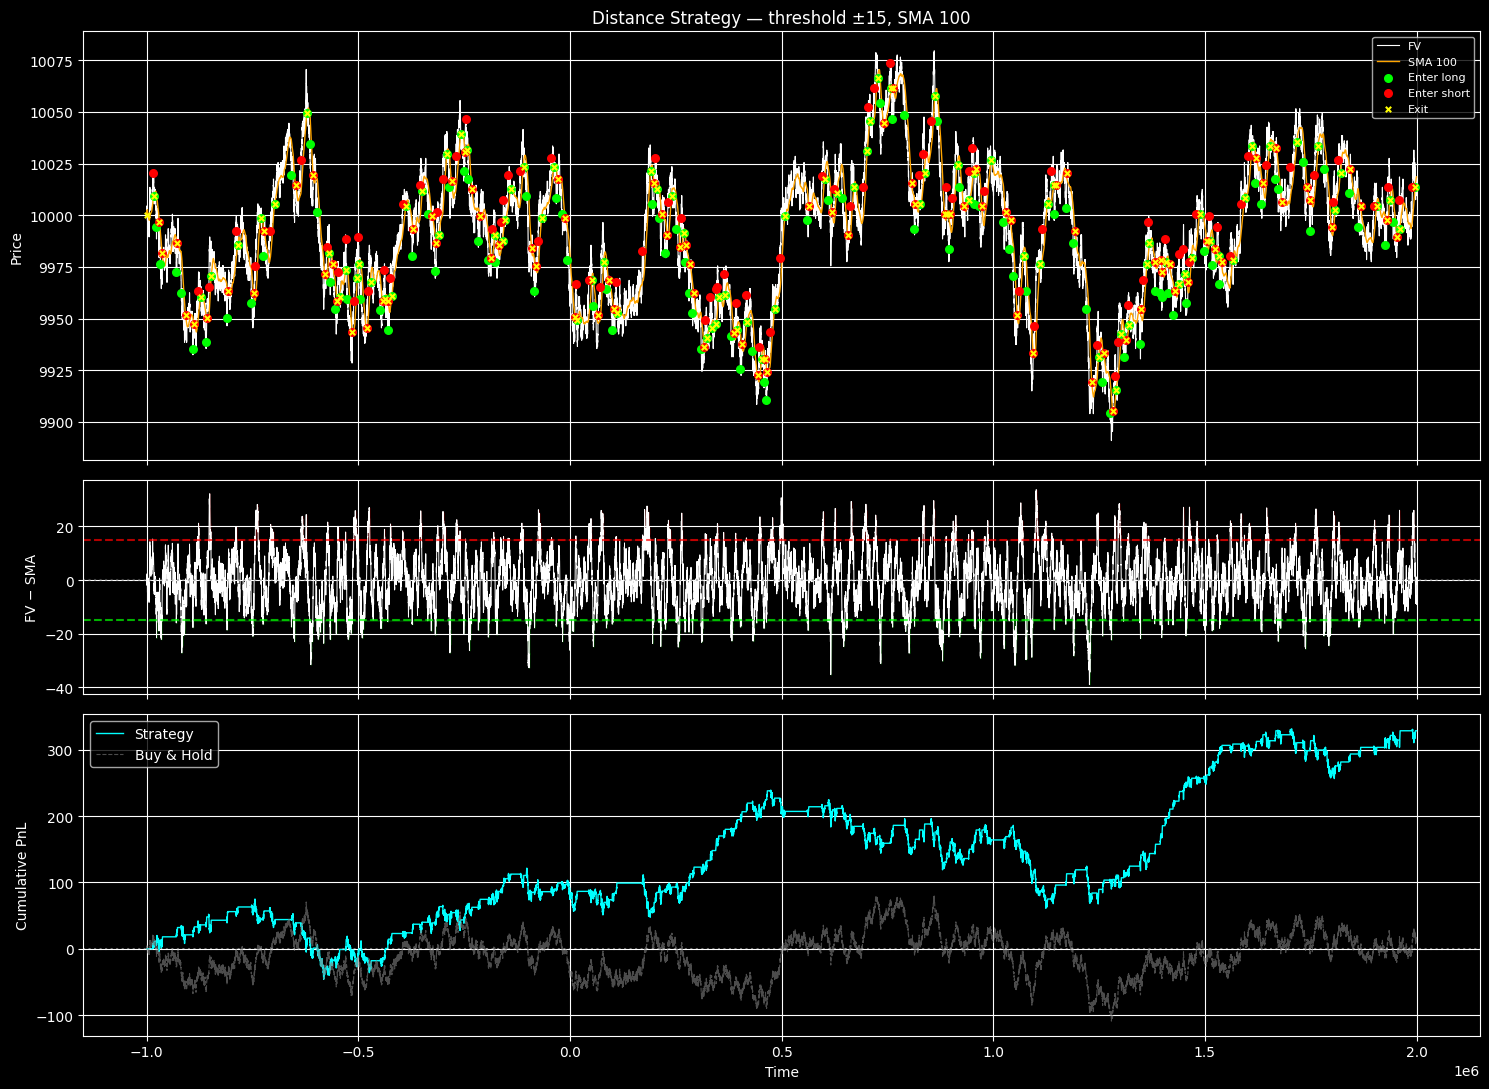

In [81]:
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1, 1.5]})

# Price + SMA + entry signals
long_entries  = bt[bt["position"].diff() ==  1]
short_entries = bt[bt["position"].diff() == -1]
exits         = bt[(bt["position"].diff() != 0) & (bt["position"] == 0)]

axes[0].plot(bt["t"], bt["fv"],  color="white",  linewidth=0.8, label="FV")
axes[0].plot(bt["t"], bt["sma"], color="orange", linewidth=1,   label=f"SMA {BT_SMA_WINDOW}")
axes[0].scatter(long_entries["t"],  long_entries["fv"],  color="lime",    s=30, zorder=5, label="Enter long")
axes[0].scatter(short_entries["t"], short_entries["fv"], color="red",     s=30, zorder=5, label="Enter short")
axes[0].scatter(exits["t"],         exits["fv"],         color="yellow",  s=15, zorder=5, marker="x", label="Exit")
axes[0].set_ylabel("Price")
axes[0].set_title(f"Distance Strategy — threshold ±{BT_THRESHOLD}, SMA {BT_SMA_WINDOW}")
axes[0].legend(fontsize=8)
axes[0].grid(True)

# Distance
axes[1].plot(bt["t"], bt["distance"], color="white", linewidth=0.7)
axes[1].axhline( BT_THRESHOLD, color="red",  linestyle="--", alpha=0.7)
axes[1].axhline(-BT_THRESHOLD, color="lime", linestyle="--", alpha=0.7)
axes[1].axhline(0,              color="gray", linestyle=":",  alpha=0.5)
axes[1].fill_between(bt["t"],  BT_THRESHOLD, bt["distance"].clip(lower= BT_THRESHOLD), color="red",  alpha=0.2)
axes[1].fill_between(bt["t"], -BT_THRESHOLD, bt["distance"].clip(upper=-BT_THRESHOLD), color="lime", alpha=0.2)
axes[1].set_ylabel("FV − SMA")
axes[1].grid(True)

# Cumulative PnL vs buy-and-hold
axes[2].plot(bt["t"], bt["cum_pnl"], color="cyan",   linewidth=1,   label="Strategy")
axes[2].plot(bt["t"], bt["bh_pnl"], color="gray",   linewidth=0.8, linestyle="--", alpha=0.6, label="Buy & Hold")
axes[2].axhline(0, color="white", linestyle=":", alpha=0.4)
axes[2].set_ylabel("Cumulative PnL")
axes[2].set_xlabel("Time")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

---
## Spread & Volume Imbalance Analysis

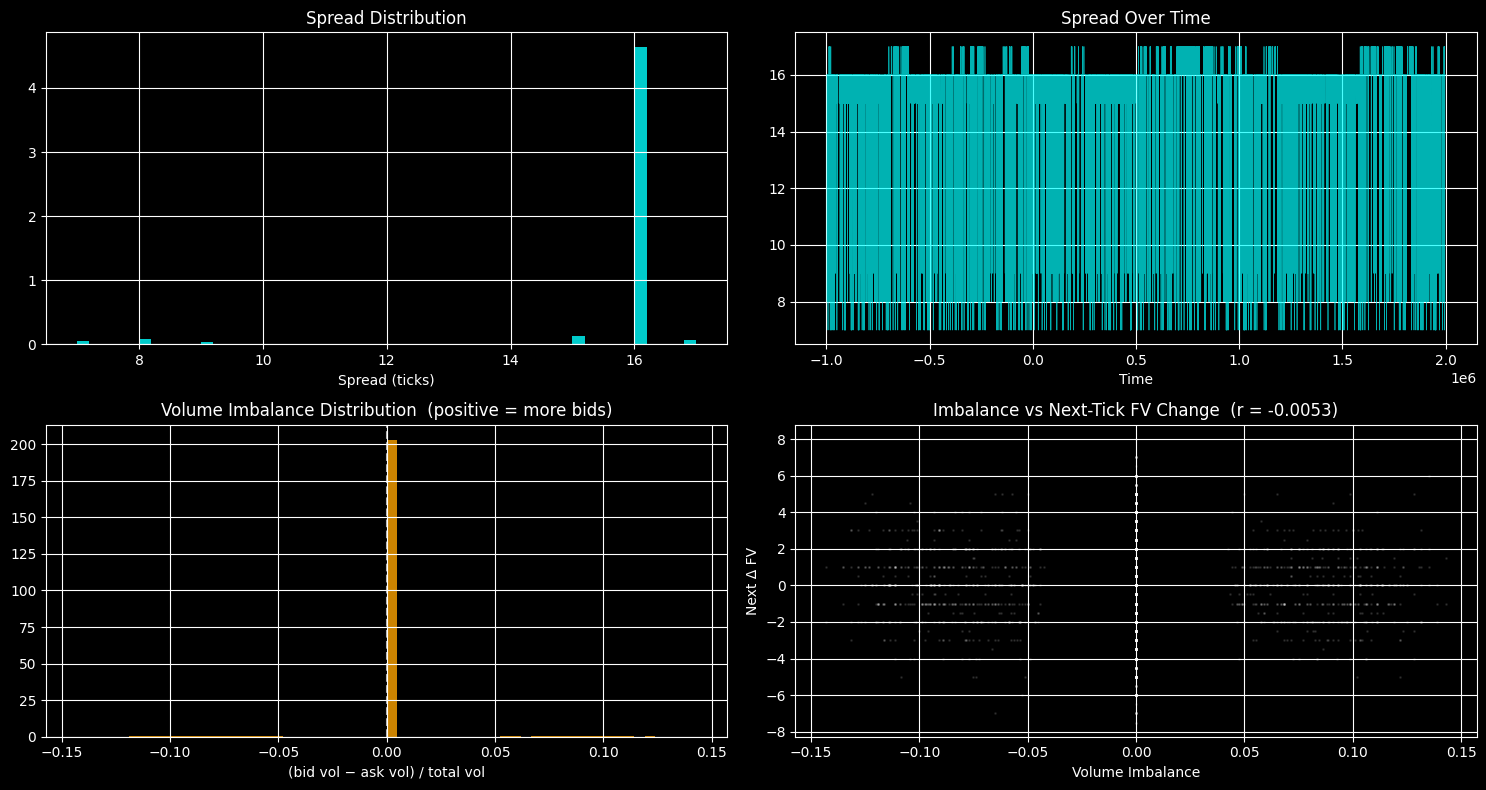

Spread — mean: 15.72  std: 1.46  min: 7  max: 17
Vol imbalance vs next return corr: -0.0053


In [82]:
# Spread distribution and volume imbalance
hydrogel["spread"] = hydrogel["ask_price_1"] - hydrogel["bid_price_1"]

total_bid_vol = hydrogel[["bid_volume_1", "bid_volume_2", "bid_volume_3"]].sum(axis=1)
total_ask_vol = hydrogel[["ask_volume_1", "ask_volume_2", "ask_volume_3"]].sum(axis=1)
hydrogel["vol_imbalance"] = (total_bid_vol - total_ask_vol) / (total_bid_vol + total_ask_vol)

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# Spread histogram
axes[0, 0].hist(hydrogel["spread"].dropna(), bins=50, color="cyan", alpha=0.8, density=True)
axes[0, 0].set_title("Spread Distribution")
axes[0, 0].set_xlabel("Spread (ticks)")
axes[0, 0].grid(True)

# Spread over time
axes[0, 1].plot(hydrogel["t"], hydrogel["spread"], color="cyan", linewidth=0.5, alpha=0.7)
axes[0, 1].set_title("Spread Over Time")
axes[0, 1].set_xlabel("Time")
axes[0, 1].grid(True)

# Volume imbalance distribution
axes[1, 0].hist(hydrogel["vol_imbalance"].dropna(), bins=60, color="orange", alpha=0.8, density=True)
axes[1, 0].axvline(0, color="white", linestyle="--", alpha=0.7)
axes[1, 0].set_title("Volume Imbalance Distribution  (positive = more bids)")
axes[1, 0].set_xlabel("(bid vol − ask vol) / total vol")
axes[1, 0].grid(True)

# Imbalance vs next-tick return (predictive power check)
hydrogel["next_fv_chg"] = hydrogel["fv"].diff().shift(-1)
imb_corr = hydrogel["vol_imbalance"].corr(hydrogel["next_fv_chg"])
axes[1, 1].scatter(hydrogel["vol_imbalance"], hydrogel["next_fv_chg"], s=1, alpha=0.1, color="white")
axes[1, 1].set_title(f"Imbalance vs Next-Tick FV Change  (r = {imb_corr:.4f})")
axes[1, 1].set_xlabel("Volume Imbalance")
axes[1, 1].set_ylabel("Next Δ FV")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

print(f"Spread — mean: {hydrogel['spread'].mean():.2f}  std: {hydrogel['spread'].std():.2f}  min: {hydrogel['spread'].min():.0f}  max: {hydrogel['spread'].max():.0f}")
print(f"Vol imbalance vs next return corr: {imb_corr:.4f}")